In [1]:
import os, sys
import numpy as np
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN
from ChebyKANLayer import ChebyKANLayer

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt
X0 = [0.1, 1.5]
Params = [1.5, 1, 2, 1]

In [3]:
models = [ChebyKAN(np.append(2, np.append(np.ones([layerCount], dtype=int) * layerSize, 2)), 4) for layerSize in range(5, 10, 2) for layerCount in range(1,5)]
kanODEs = [KANODE(model, pred_prey_deriv, X0, Params, 20, 7.5, 150) for model in models]

 57%|█████▋    | 5669/10000 [5:46:19<4:24:34,  3.67s/it]


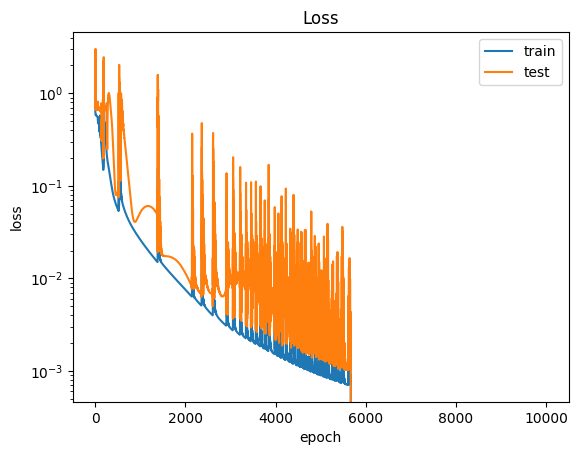

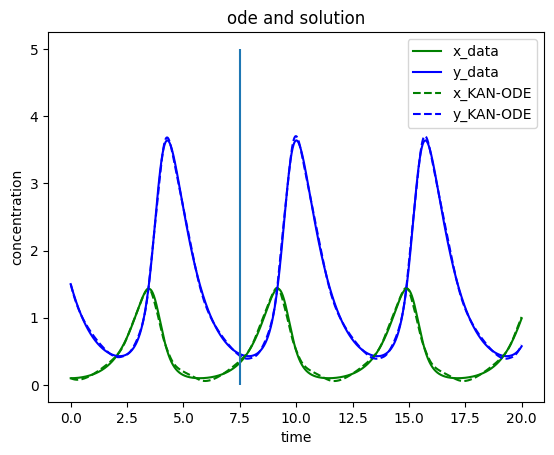

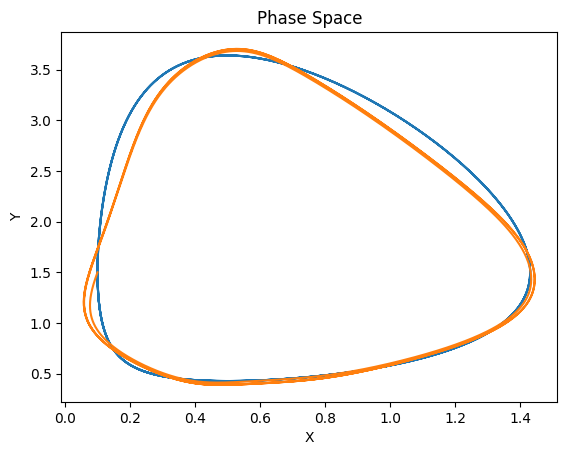

layerSize-5_layerCount-1


 27%|██▋       | 2740/10000 [5:17:43<14:01:52,  6.96s/it]


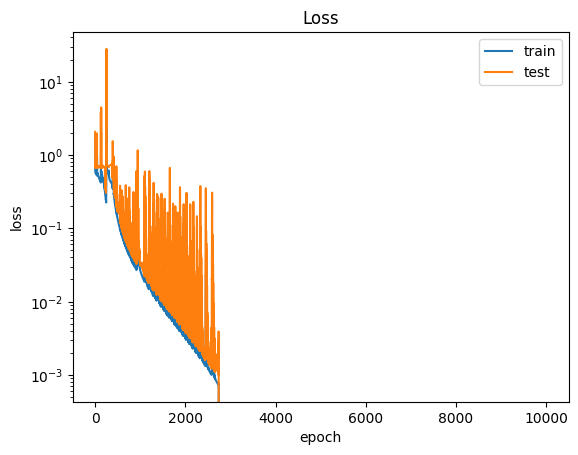

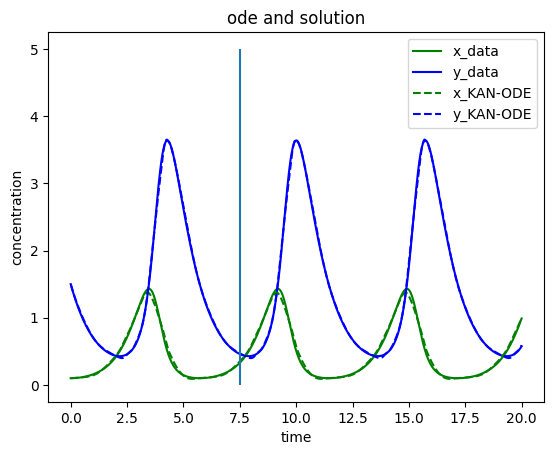

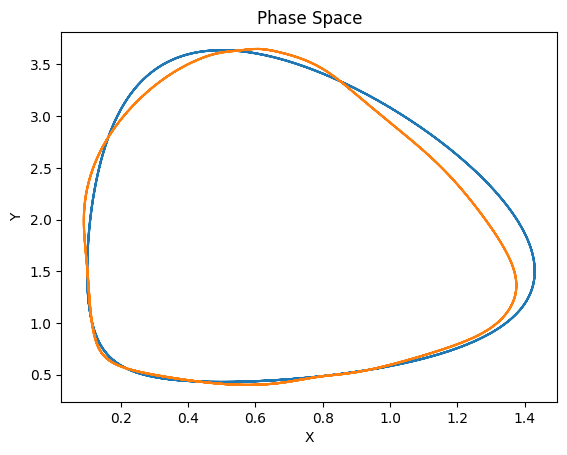

layerSize-5_layerCount-3


100%|██████████| 10000/10000 [21:25:27<00:00,  7.71s/it]  


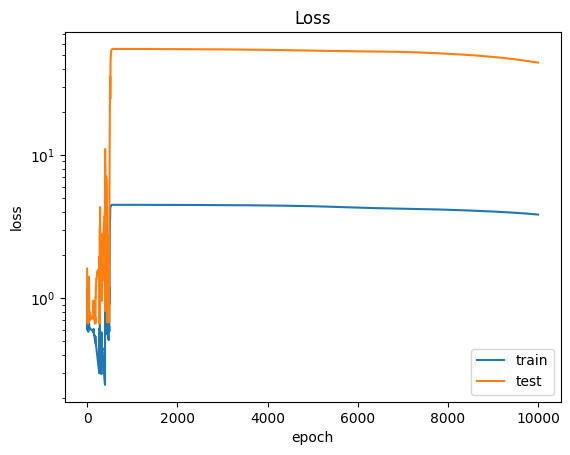

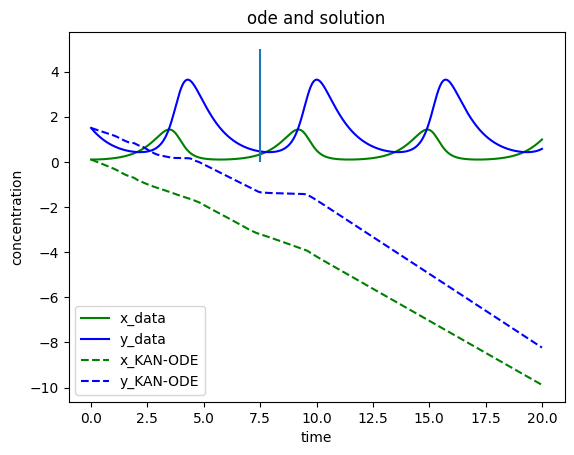

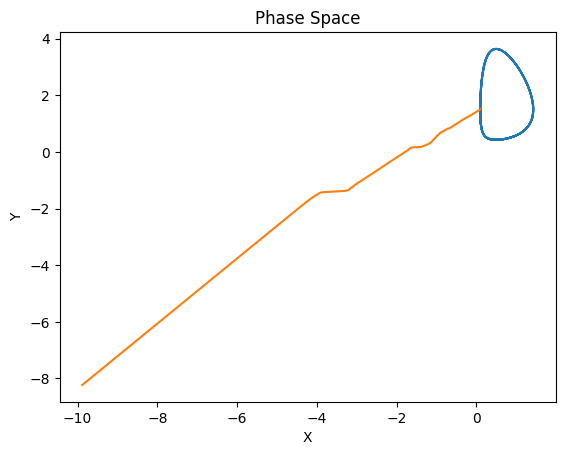

layerSize-5_layerCount-4


 65%|██████▍   | 6470/10000 [6:26:30<3:30:52,  3.58s/it]


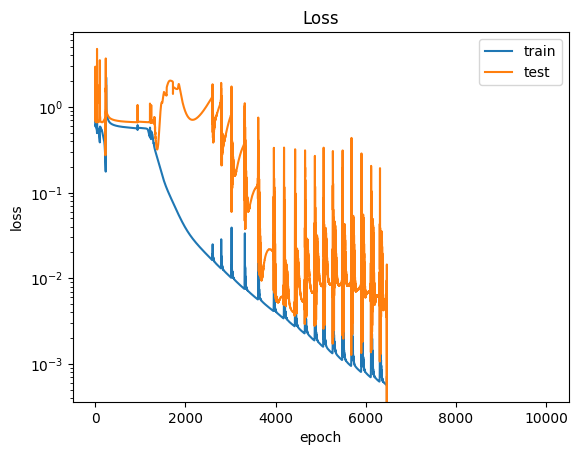

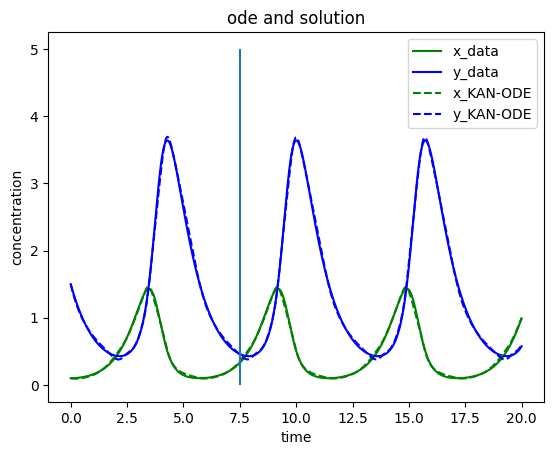

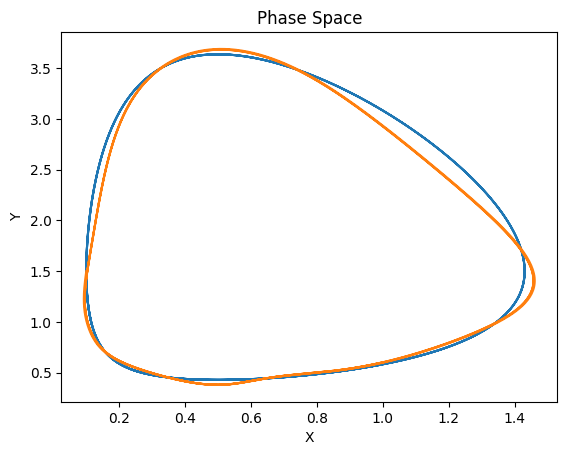

layerSize-7_layerCount-1


 11%|█         | 1075/10000 [1:33:19<12:54:46,  5.21s/it]


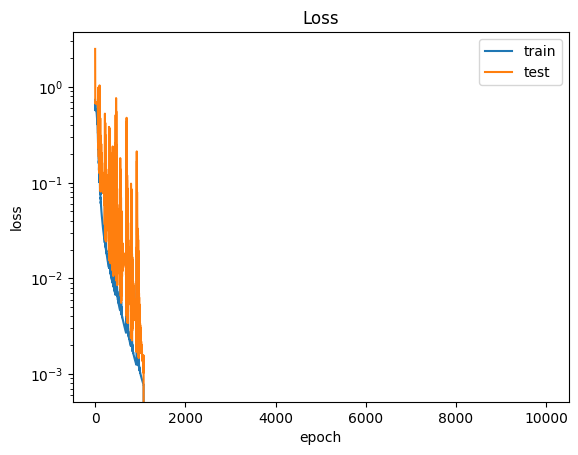

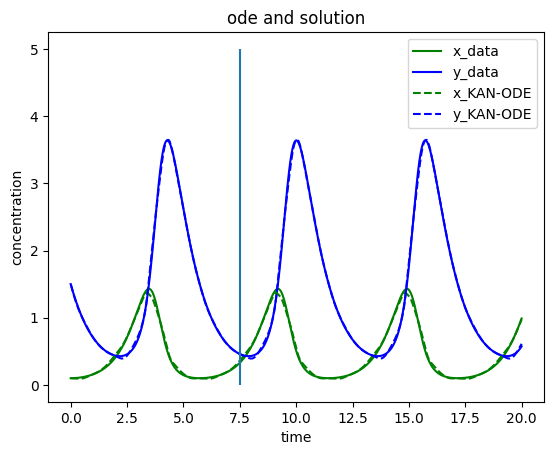

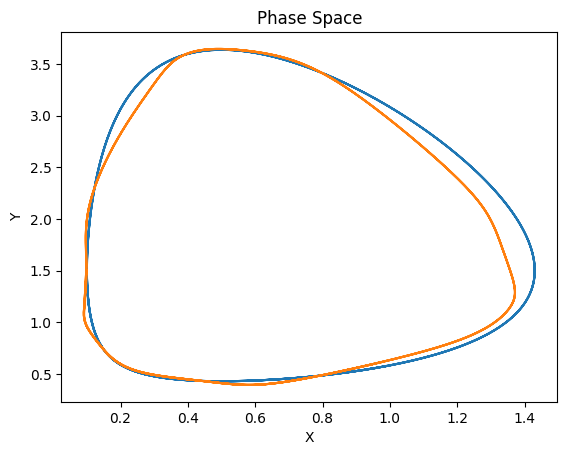

layerSize-7_layerCount-2


100%|██████████| 10000/10000 [18:48:45<00:00,  6.77s/it] 


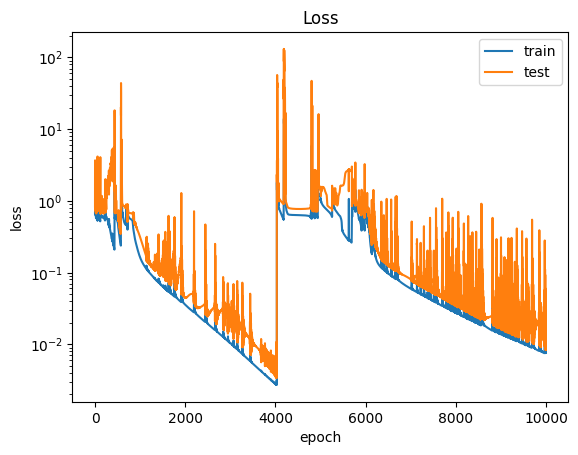

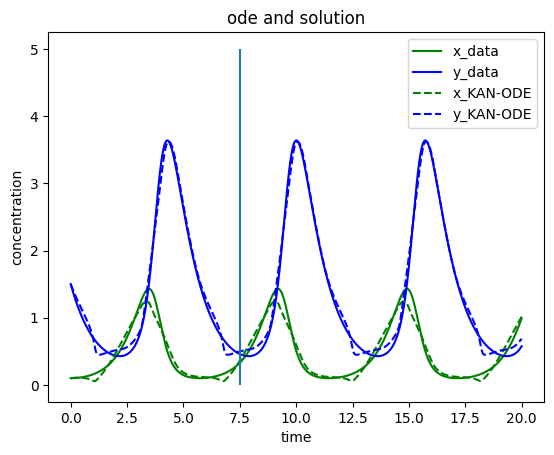

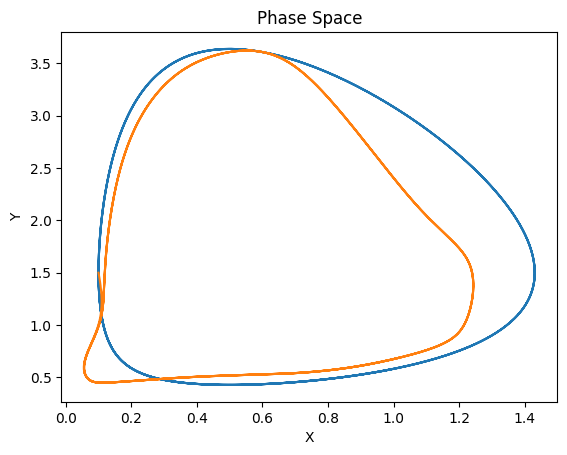

layerSize-7_layerCount-3


 80%|████████  | 8031/10000 [19:53:20<4:52:34,  8.92s/it] 


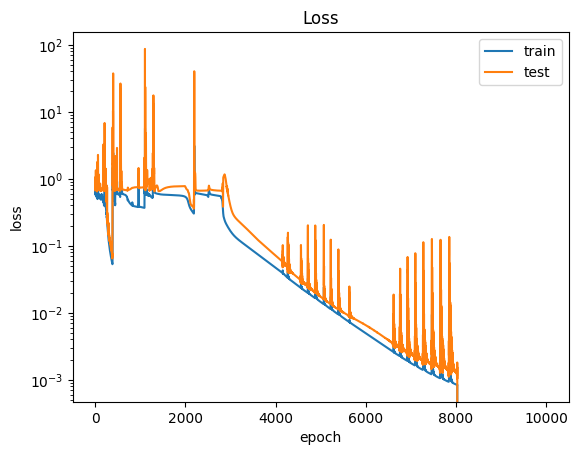

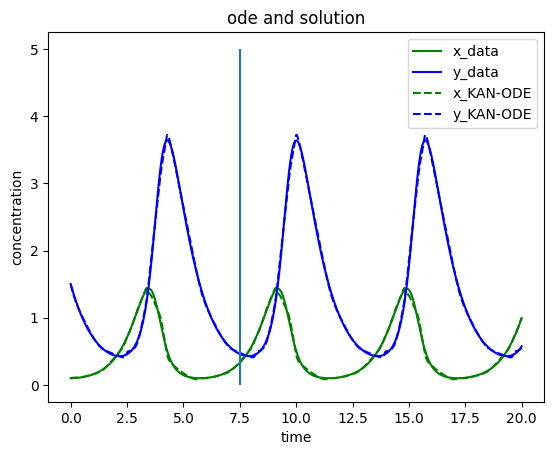

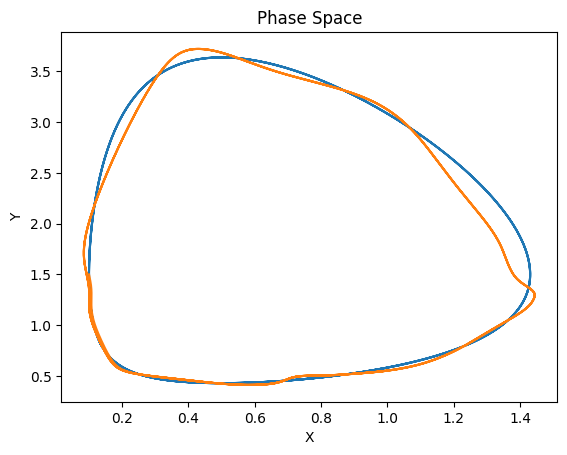

layerSize-7_layerCount-4


 70%|███████   | 7047/10000 [7:31:12<3:09:04,  3.84s/it]


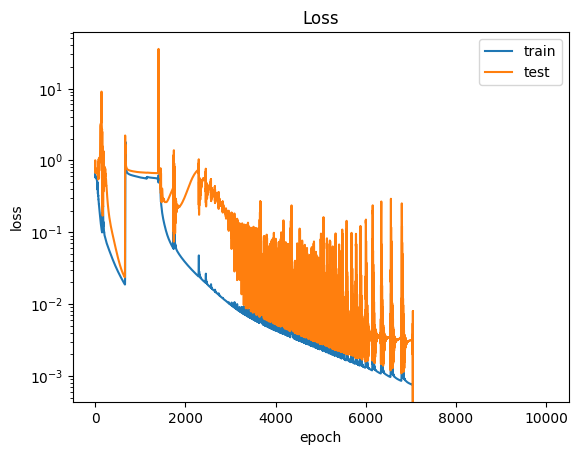

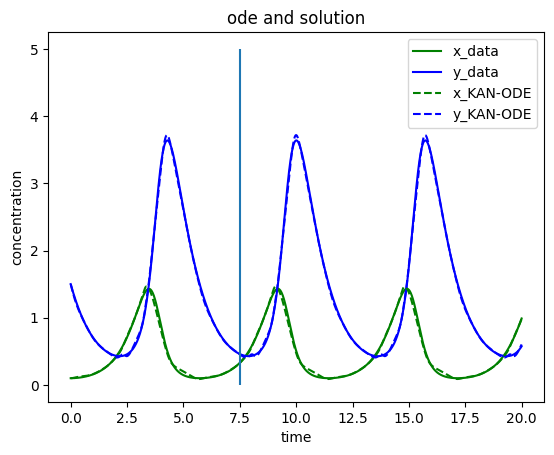

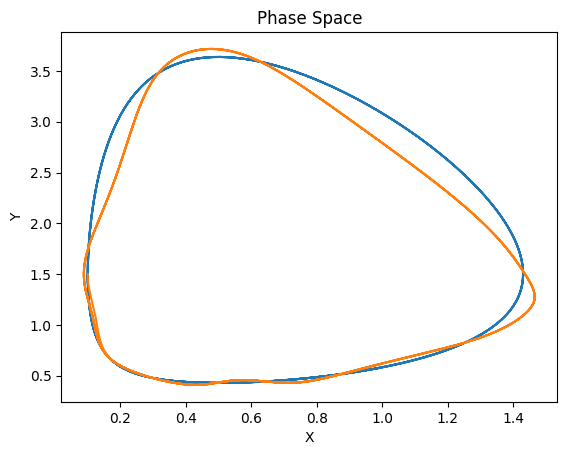

layerSize-9_layerCount-1


 48%|████▊     | 4847/10000 [6:48:53<7:14:41,  5.06s/it] 


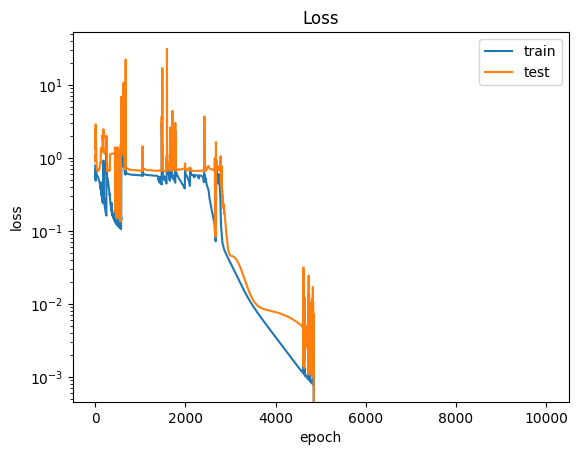

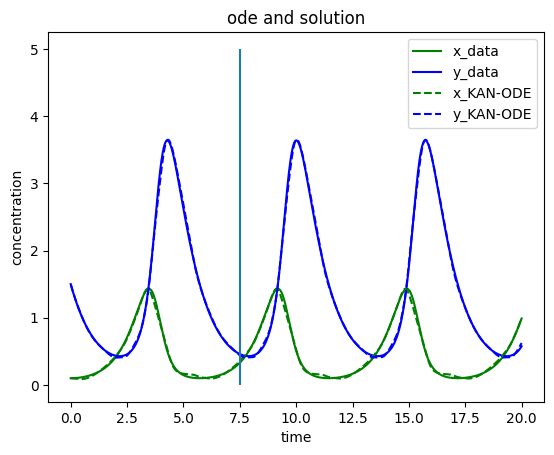

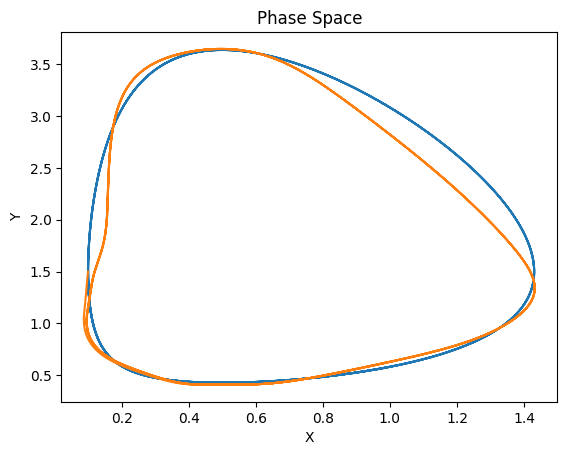

layerSize-9_layerCount-2


 22%|██▏       | 2223/10000 [4:11:22<14:39:26,  6.78s/it]


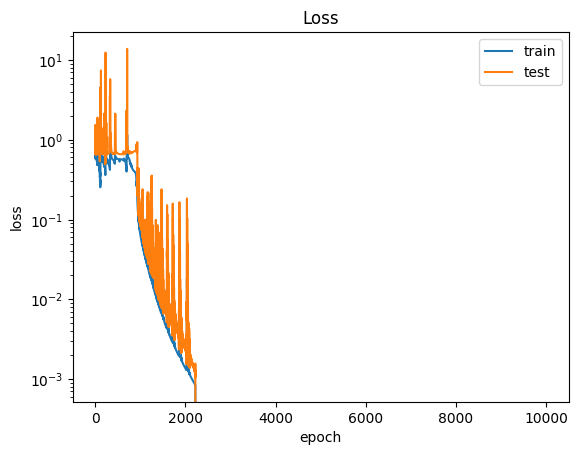

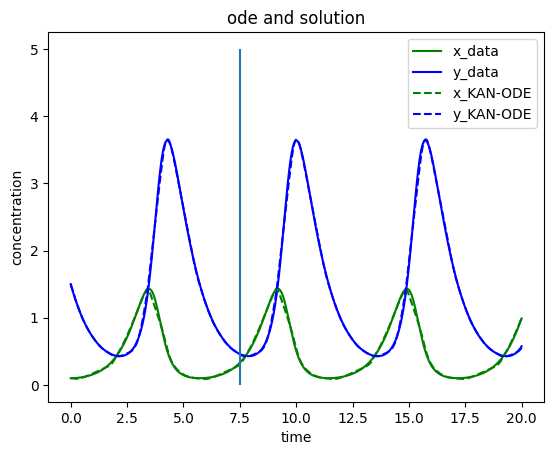

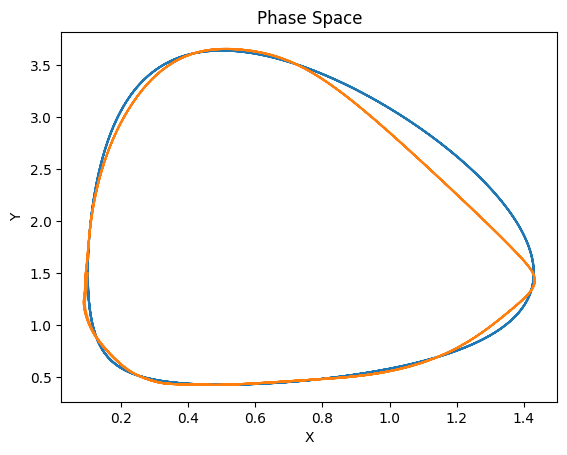

layerSize-9_layerCount-3


 35%|███▌      | 3537/10000 [8:21:15<15:15:55,  8.50s/it]


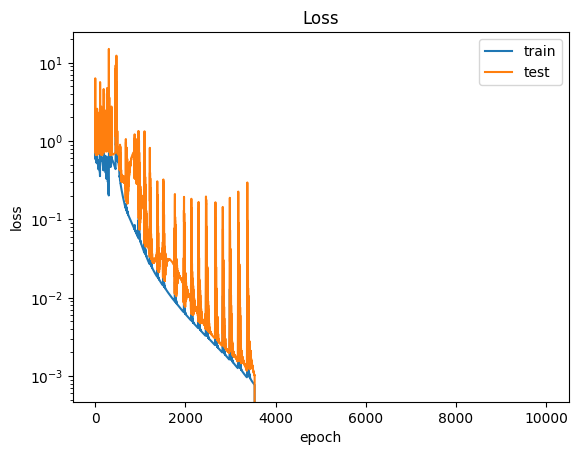

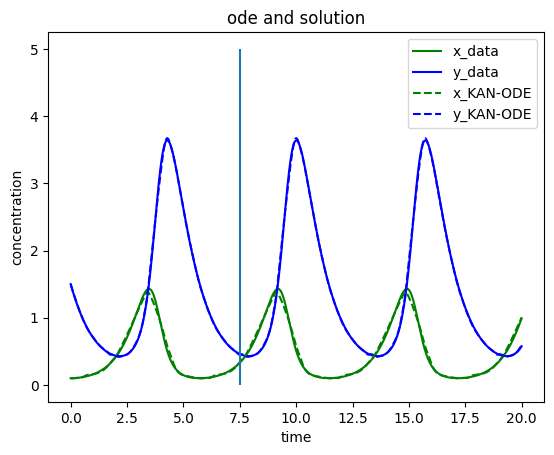

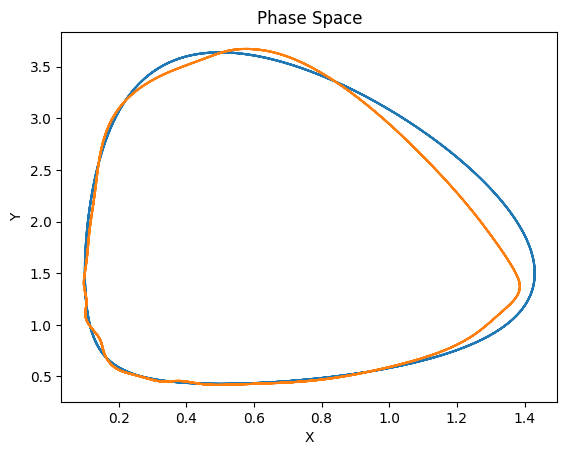

layerSize-9_layerCount-4


In [4]:
for kanODE in kanODEs:
    try:
        saveDirectory = os.path.join(module_path, "savedModels", "structureSweep1", "rk4", f"layerSize-{kanODE.model.layers[0].outdim}_layerCount-{len(kanODE.model.layers)-1}")
        os.makedirs(saveDirectory)
        kanODE.train(-1, saveDirectory=saveDirectory, saveCooldown=100, evalThreshold=10**-3, solverMethod="rk4")
        _, solution = kanODE.test()
        kanODE.plotLoss("Loss")
        kanODE.plotODE("ode and solution", solution[:, 0, :])
        kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])
        print(f"layerSize-{kanODE.model.layers[0].outdim}_layerCount-{len(kanODE.model.layers)-1}")
    except:
        continue